In [ ]:
# Conext of the word matters

sentences = [
    "I went to the bank",
    "He sat on the river bank",
    "She deposited money in the bank"
]

# Order of the Word Matters

print("dog bites man")
print("man bites dog")


text = "machine learning is fun and machine learning is powerful"
set(text.split())

In [4]:
from nltk.tokenize import TreebankWordTokenizer

tokenizer = TreebankWordTokenizer()

sentence = "She deposited money in the bank"
tokens = tokenizer.tokenize(sentence)

tokens


['She', 'deposited', 'money', 'in', 'the', 'bank']

In [5]:
sentences = [
    "She deposited money in the bank",
    "She sat near the river bank"
]

for s in sentences:
    print(tokenizer.tokenize(s))


['She', 'deposited', 'money', 'in', 'the', 'bank']
['She', 'sat', 'near', 'the', 'river', 'bank']


In [7]:
# building vocal with tokens

tokens = ['She', 'deposited', 'money', 'in', 'the', 'bank']

vocab = {word: idx for idx, word in enumerate(sorted(set(tokens)))}

# token IDs

token_ids = [vocab[token] for token in tokens]

print(f'Vocabulary: {vocab}')
print(f'Token IDs: {token_ids}')


Vocabulary: {'She': 0, 'bank': 1, 'deposited': 2, 'in': 3, 'money': 4, 'the': 5}
Token IDs: [0, 2, 4, 3, 5, 1]


In [ ]:
# Count Vectorization

# Vocabulary Size -> Vector Size

from sklearn.feature_extraction.text import CountVectorizer

corpus = [
    "She deposited money in the bank",
    "She sat near the river bank"
]

vectorizer = CountVectorizer()
X_bow = vectorizer.fit_transform(corpus)

X_bow.toarray()


array([[1, 1, 1, 1, 0, 0, 0, 1, 1],
       [1, 0, 0, 0, 1, 1, 1, 1, 1]])

In [ ]:
# TF - IDF
# Term Frequency - Inverse Document Frequency

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(corpus)

X_tfidf.toarray()


array([[0.33471228, 0.47042643, 0.47042643, 0.47042643, 0.        ,
        0.        , 0.        , 0.33471228, 0.33471228],
       [0.33471228, 0.        , 0.        , 0.        , 0.47042643,
        0.47042643, 0.47042643, 0.33471228, 0.33471228]])

In [10]:
from sklearn.metrics.pairwise import cosine_similarity
cosine_similarity(X_bow)


array([[1. , 0.5],
       [0.5, 1. ]])

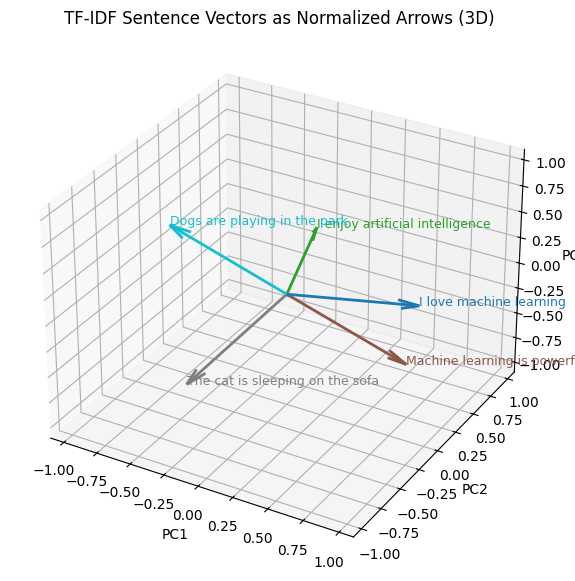

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Sentences (documents)
sentences = [
    "I love machine learning",
    "I enjoy artificial intelligence",
    "Machine learning is powerful",
    "The cat is sleeping on the sofa",
    "Dogs are playing in the park"
]

# TF-IDF vectorization
vectorizer = TfidfVectorizer()
X_tfidf = vectorizer.fit_transform(sentences)

# PCA to 3D
pca = PCA(n_components=3)
X_3d = pca.fit_transform(X_tfidf.toarray())

# 🔑 Normalize vectors (keeps arrows inside plot & fixes proportions)
X_3d_norm = normalize(X_3d)

# Colors (one per arrow)
colors = plt.cm.tab10(np.linspace(0, 1, len(sentences)))

# Plot
fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection="3d")

for i, sentence in enumerate(sentences):
    ax.quiver(
        0, 0, 0,
        X_3d_norm[i,0],
        X_3d_norm[i,1],
        X_3d_norm[i,2],
        color=colors[i],
        linewidth=2,
        arrow_length_ratio=0.15   # Proper arrowhead proportion
    )
    ax.text(
        X_3d_norm[i,0],
        X_3d_norm[i,1],
        X_3d_norm[i,2],
        sentence,
        fontsize=9,
        color=colors[i]
    )

# Axis limits (keeps everything visible)
ax.set_xlim([-1.1, 1.1])
ax.set_ylim([-1.1, 1.1])
ax.set_zlim([-1.1, 1.1])

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("TF-IDF Sentence Vectors as Normalized Arrows (3D)")

plt.show()


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

query = "I like machine learning"

query_vec = vectorizer.transform([query])

print(query_vec)

scores = cosine_similarity(query_vec, X_tfidf)[0]

results = sorted(
    zip(sentences, scores),
    key=lambda x: x[1],
    reverse=True
)

results
